In [1]:
import pandas as pd
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import numpy as np
import random
import inflect


In [2]:
clinical_included_ids_file = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/06_preclin_clinic_join/data/clinical/clinical_inlcuded_18609_nctids.csv"
included_nctids = pd.read_csv(clinical_included_ids_file)


### ideas (not yet implemented)
- remove known generics?
- singularize -> cases like "antidepressants" vs "antidepressant"
- would reduce noise

In [3]:
import re

JUNK_PATTERNS = [
    r'^\s*["\']?\s*#?\s*\d+\s*[,"\']?\s*$',  # " 528', '# 0451', '# 2714', 528, 1,234
]

def _is_junk_token(tok: str) -> bool:
    """Return True if token is meaningless junk like '# 0451', '" 528\'', '()', etc."""
    s = tok.strip().strip('"').strip("'").strip()

    # Empty or one-character junk
    if not s or len(s) < 2:
        return True

    # Pure punctuation / brackets / quotes / plus/minus
    if re.fullmatch(r"^[\(\)\[\]\{\}\'\"\,\.\#\s\-\_\+\=]+$", s):
        return True

    # Numeric garbage possibly prefixed/suffixed by punctuation
    if re.fullmatch(r'^[#\s\'\"\(\)\+\-]*\d+[\'\"\)\s,]*$', s):
        return True

    # Hash-prefixed or leading garbage like '# #', '# 0451'
    if s.startswith("#") and not re.search(r"[A-Za-z]", s):
        return True

    # Junk like empty parentheses or stray symbols
    if s in {"()", "( )", "''", '""', "''", "'"}:
        return True

    return False


def clean_predictions(drugs_list: str) -> str:
    """
    Clean and normalize a pipe-separated list of drug names.
    Removes artifacts (like '# # 45-65-nh2', '" 528'), filters mechanistic terms,
    and maps known synonyms to canonical drug names.
    Keeps valid names like 'mir-1192' or 'antagomir-21' intact.
    """
    if not isinstance(drugs_list, str) or not drugs_list.strip():
        return drugs_list

    drug_names = drugs_list.split("|")
    drug_names_clean = set()

    for drug_name in drug_names:
        dn = drug_name.strip().strip('"').strip("'").strip()

        # Junk or meaningless tokens
        if _is_junk_token(dn):
            continue

        # Skip mechanistic/generic category terms
        if any(word in dn.lower() for word in [
            "antibody", "channel", "receptor", "modulator",
            "blocker", "agonist", "antagonis", "anti-", "inhibitor"
        ]):
            continue

        # Canonical name mappings (case-insensitive)
        ln = dn.lower()
        if ln in ["fty720-c2", "fingolimod-1 phosphate"]:
            dn = "Fingolimod"
        elif ln in [
            "1,25-dihydroxyvitamin d", "1alpha,25-dihydroxyvitamin d",
            "vitamin d", "vitamin d3", "calcitriol", "cholecalciferol"
        ]:
            dn = "vitamin D3"
        elif ln in ["beta interferon", "interferon beta (recombinant)"]:
            dn = "beta 1 Interferon"

        # Valid alphanumeric-hyphen pattern (keep mir-1192, agomir-21, etc.)
        if not re.match(r'^[A-Za-z0-9\-\s\(\)]+$', dn):
            continue

        # Too short or empty
        if not dn or len(dn) < 2:
            continue

        drug_names_clean.add(dn)

    # Return cleaned list or fallback to original
    return "|".join(sorted(drug_names_clean)) if drug_names_clean else drugs_list


In [4]:
#preclinical_df["merged_umls_label_manual_clean"] = preclinical_df['merged_umls_label'].apply(lambda x: clean_predictions(x))

#n_unique, freq = count_unique_from_pipe_column(preclinical_df, "merged_umls_label_manual_clean")
#print(f"Unique count: {n_unique}")

## code for stats

In [5]:
import pandas as pd

def add_unique_entity_count(
    df: pd.DataFrame,
    col: str,
    *,
    sep: str = "|",
    case_insensitive: bool = True,
    new_col: str | None = None,
) -> pd.DataFrame:
    """
    Add a column counting unique entities per row from a pipe-separated column.

    Parameters
    ----------
    df : pd.DataFrame
        Input dataframe.
    col : str
        Column containing pipe-separated entities.
    sep : str, default "|"
        Separator used in the column.
    case_insensitive : bool, default True
        Whether to normalize entities to lowercase before counting.
    new_col : str, optional
        Name of the new column. Defaults to `{col}_unique_count`.

    Returns
    -------
    pd.DataFrame
        Copy of dataframe with the added unique-count column.
    """
    df = df.copy()
    out_col = new_col or f"{col}_unique_count"

    def count_unique(val):
        if pd.isna(val):
            return 0
        items = [
            v.strip().lower() if case_insensitive else v.strip()
            for v in str(val).split(sep)
            if v.strip()
        ]
        return len(set(items))

    df[out_col] = df[col].apply(count_unique)
    return df


In [6]:
def no_linked_entities(termids: str) -> bool:
    """
    Return True if NONE of the entities were linked.
    Condition:
      - all values == '-1'
      - or empty / None / whitespace
    """
    if not termids:  # None or empty string
        return True
    
    # Split and clean
    parts = [p.strip() for p in str(termids).split("|") if p.strip()]

    if not parts:
        return True  # nothing there → no linked entities

    # True only if every part is '-1'
    return all(p == "-1" for p in parts)


In [7]:
import inflect

_inflect = inflect.engine()

In [8]:
def _split_terms(val, *, sep="|"):
    """Split a sep-joined cell into stripped, non-empty tokens."""
    if val is None:
        return []
    return [t.strip() for t in str(val).split(sep) if t and t.strip()]

def _to_singular_word(word: str) -> str:
    """Singularize a single word safely."""
    if not word:
        return word
    try:
        s = _inflect.singular_noun(word)
    except TypeError:
        return word
    return s if isinstance(s, str) and s else word

def _to_singular(text: str) -> str:
    """
    Singularize only the last whitespace token.
    This is safer than passing full multi-word terms into inflect.
    """
    if not text:
        return text
    parts = text.split()
    if not parts:
        return text
    parts[-1] = _to_singular_word(parts[-1])
    return " ".join(parts)

def _norm_term(
    t: str,
    *,
    case_insensitive: bool,
    singularize: bool = False,
):
    t = "" if t is None else str(t).strip()
    if case_insensitive:
        t = t.lower()
    if singularize and t:
        t = _to_singular(t)
    return t

def _valid_term(t: str, *, ignore_short: bool):
    return (len(t) > 2) if ignore_short else True

def _unique_terms(
    series: pd.Series,
    *,
    sep="|",
    case_insensitive=True,
    singularize=False,
    ignore_short=True,
) -> set:
    out = set()
    for cell in series.fillna(""):
        for t in _split_terms(cell, sep=sep):
            t = _norm_term(t, case_insensitive=case_insensitive, singularize=singularize)
            if _valid_term(t, ignore_short=ignore_short):
                out.add(t)
    return out

def clean_pipe_split(
    s,
    sep: str = "|",
    *,
    case_insensitive: bool = True,
    singularize: bool = False,
    ignore_short_entities: bool = False,
):
    toks = _split_terms(s, sep=sep)
    out = []
    for t in toks:
        t = _norm_term(t, case_insensitive=case_insensitive, singularize=singularize)
        if not t:
            continue
        if ignore_short_entities and not _valid_term(t, ignore_short=True):
            continue
        out.append(t)
    return out

def _split_raw(s, sep="|"):
    return [t.strip() for t in str(s or "").split(sep) if t and t.strip()]


In [9]:
def summarize_entity_mappings(
    df,
    norm_col: str,
    id_col: str,
    ner_col: str,
    doc_id_col: str = "PMID",
    ignore_id: str = "-1",
    ignore_short_entities: bool = True,
    *,
    sep: str = "|",
    case_insensitive: bool = True,
    singularize: bool = False,
):
    unique_entities_with_mappings = {}
    entity_frequency = defaultdict(int)
    mapped_to_ner = defaultdict(set)

    print(f"Summarizing entity mappings for {norm_col}, {id_col}")

    for _, row in df.iterrows():
        doc_id = row.get(doc_id_col, "")

        # split-only for alignment
        norm_raw = _split_raw(row.get(norm_col), sep=sep)
        ids_raw  = _split_raw(row.get(id_col),  sep=sep)
        ner_raw  = _split_raw(row.get(ner_col), sep=sep)

        # names vs ids must align (RAW)
        if len(norm_raw) != len(ids_raw):
            print(f"ERROR (names vs mappings length) {doc_id_col} {doc_id}")
            print(f"  {norm_col}: {norm_raw}")
            print(f"  {id_col}  : {ids_raw}")
            continue

        # normalize/filter AFTER alignment, inside the zip
        norm_vals = []
        id_vals = []
        for ent, mid in zip(norm_raw, ids_raw):
            ent_n = _norm_term(ent, case_insensitive=case_insensitive, singularize=singularize)
            mid = mid.strip()
            if not ent_n:
                continue
            if ignore_short_entities and len(ent_n) <= 2:
                continue
            norm_vals.append(ent_n)
            id_vals.append(mid)

            unique_entities_with_mappings.setdefault(ent_n, mid)
            entity_frequency[ent_n] += 1

        # names vs NER alignment is optional; check RAW to avoid false notes
        if len(norm_raw) != len(ner_raw):
            print(
                f"NOTE (names vs NER length) {doc_id_col} {doc_id}:\n"
                f"  → {len(norm_raw)} names vs {len(ner_raw)} NER tokens\n"
                f"  names: {norm_raw}\n"
                f"  ner  : {ner_raw}\n"
            )
            continue

        # mapped_to_ner: align RAW triples, then normalize/filter
        for ent, mid, ner_tok in zip(norm_raw, ids_raw, ner_raw):
            ent_n = _norm_term(ent, case_insensitive=case_insensitive, singularize=singularize)
            ner_n = _norm_term(ner_tok, case_insensitive=case_insensitive, singularize=singularize)
            mid = mid.strip()
            if not ent_n:
                continue
            if ignore_short_entities and len(ent_n) <= 2:
                continue
            if mid != ignore_id and ner_n:
                key = f"{ent_n} ({mid})"
                mapped_to_ner[key].add(ner_n)

    mapped_to_ner_df = (
        pd.DataFrame(
            [
                {
                    "entity_mapping": key,
                    "entity": key.split("(")[0].strip(),
                    "mapping": key.split("(")[1].rstrip(")").strip(),
                    "ner_tokens": sorted(values),
                    "ner_count": len(values),
                }
                for key, values in mapped_to_ner.items()
            ]
        )
        .sort_values(by="ner_count", ascending=False)
        .reset_index(drop=True)
    )

    return unique_entities_with_mappings, entity_frequency, mapped_to_ner, mapped_to_ner_df


In [10]:
def entity_linking_report(
    df: pd.DataFrame,
    *,
    norm_col: str,
    id_col: str,
    ner_col: str,
    parent_label_col: str,
    clean_label_col: str | None = None,
    doc_id_col: str = "PMID",
    ignore_id: str = "-1",
    sep: str = "|",
    case_insensitive: bool = True,
    singularize: bool = False,
    round_digits: int = 2,
    ignore_short_entities: bool = True,
):
    # detailed summary on normalized entities
    unique_norm_to_id, norm_freq, mapped_to_ner, mapped_to_ner_df = summarize_entity_mappings(
        df=df,
        norm_col=norm_col,
        id_col=id_col,
        ner_col=ner_col,
        doc_id_col=doc_id_col,
        ignore_id=ignore_id,
        ignore_short_entities=ignore_short_entities,
        singularize=singularize
    )
    # detailed summary on normalized entities
    if "umls" in parent_label_col:
        id_col_parent = "merged_umls_termid"
    else:
        id_col_parent = "merged_mondo_termid"
    
    unique_norm_to_id_with_parent, _, _, _ = summarize_entity_mappings(
        df=df,
        norm_col=parent_label_col,
        id_col=id_col_parent,
        ner_col=parent_label_col,
        doc_id_col=doc_id_col,
        ignore_id=ignore_id,
        ignore_short_entities=ignore_short_entities,
        singularize=singularize
    )

    if ignore_short_entities:
        print("Only entities with more than 2 characters are considered.")
    if singularize:
        print("Inflecting to singular forms.")

    # unique counts (raw, linked, linked+parent, optional clean)
    raw_set    = _unique_terms(df[ner_col],          sep=sep, case_insensitive=case_insensitive, singularize=singularize, ignore_short=ignore_short_entities)
    linked_set = _unique_terms(df[norm_col],         sep=sep, case_insensitive=case_insensitive, singularize=singularize, ignore_short=ignore_short_entities)
    parent_set = _unique_terms(df[parent_label_col], sep=sep, case_insensitive=case_insensitive, singularize=singularize, ignore_short=ignore_short_entities)

    count_unique_raw = len(raw_set)
    count_unique_linked = len(linked_set)
    count_unique_with_parent = len(parent_set)

    count_unique_clean = None
    if clean_label_col and clean_label_col in df.columns:
        clean_set = _unique_terms(df[clean_label_col], sep=sep, case_insensitive=case_insensitive, ignore_short=ignore_short_entities)
        count_unique_clean = len(clean_set)

    # --- linking success computed from RAW tokens aligned with IDs ---
    raw_freq = Counter()        # raw -> mentions
    raw_to_first_id = {}        # raw -> first id at same position
    mismatch_rows = 0

    for row in df[[ner_col, id_col]].itertuples(index=False, name=None):
        raw_cell, id_cell = row
        raw_vals = _split_terms(raw_cell, sep=sep)
        id_vals  = _split_terms(id_cell,  sep=sep)

        if len(raw_vals) != len(id_vals):
            mismatch_rows += 1

        for raw, mid in zip(raw_vals, id_vals):
            raw_key = _norm_term(raw, case_insensitive=case_insensitive, singularize=singularize)
            if not _valid_term(raw_key, ignore_short=ignore_short_entities):
                continue
            raw_freq[raw_key] += 1
            raw_to_first_id.setdefault(raw_key, mid)

    total_mentions = sum(raw_freq.values())

    # unique raw terms that map to a real ID
    mapped_unique_raw = sum(1 for mid in raw_to_first_id.values() if mid != ignore_id)

    # mentions whose (first-seen) ID is not ignore_id
    mapped_mentions = sum(
        freq for raw_key, freq in raw_freq.items()
        if raw_to_first_id.get(raw_key, ignore_id) != ignore_id
    )

    pct_mapped_unique = (mapped_unique_raw / count_unique_raw * 100) if count_unique_raw else 0.0
    pct_mapped_mentions = (mapped_mentions / total_mentions * 100) if total_mentions else 0.0

    report_row = {
        "total mentions": total_mentions,
        "count unique raw entities": count_unique_raw,
        "count unique linked entities": count_unique_linked,
        "count unique linked with parent": count_unique_with_parent,
        "Linking success (unique / % mapped freq adjusted)": (
            f"{mapped_unique_raw} ({round(pct_mapped_unique, round_digits)}%)/"
            f"{count_unique_raw} ({round(pct_mapped_mentions, round_digits)}%)"
        ),
        "mismatch rows (raw vs id length)": mismatch_rows,
    }

    if count_unique_clean is not None:
        report_row["count unique clean labels"] = count_unique_clean # MONDO entities had an extra post-processing step

    report = pd.DataFrame([report_row])

    details = {
        "unique_norm_to_id": unique_norm_to_id,
        "unique_norm_to_id_with_parent":unique_norm_to_id_with_parent,
        "norm_frequency": norm_freq,
        "mapped_to_ner": mapped_to_ner,
        "mapped_to_ner_df": mapped_to_ner_df,
        "raw_frequency": raw_freq,
        "raw_to_first_id": raw_to_first_id,
    }

    return report, details


In [11]:
def top_mapped_unmapped_side_by_side(
    unique_entities_with_mappings: dict,
    entity_frequency: dict,
    *,
    entity_name: str = "entity",
    unmapped_id: str = "-1",
    top_n: int = 10,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Build a frequency table for entities, then return top-N mapped and unmapped
    entities side-by-side.

    Parameters
    ----------
    unique_entities_with_mappings : dict
        entity -> mapping_id (first seen mapping)
    entity_frequency : dict
        entity -> frequency / mentions
    entity_name : str
        Label used for the entity column in outputs (e.g. 'drug', 'disease')
    unmapped_id : str
        Value representing no mapping (default '-1')
    top_n : int
        Number of top mapped/unmapped to return

    Returns
    -------
    entity_df : DataFrame
        Full entity table: [entity, mapping, frequency, is_mapped]
    mapped_top : DataFrame
        Top-N mapped entities by frequency
    unmapped_top : DataFrame
        Top-N unmapped entities by frequency
    side_by_side : DataFrame
        Two tables concatenated horizontally: mapped vs unmapped
    """
    # Full table
    entity_df = pd.DataFrame([
        {
            entity_name: ent,
            "mapping": unique_entities_with_mappings.get(ent),
            "frequency": int(entity_frequency.get(ent, 0)),
        }
        for ent in unique_entities_with_mappings.keys()
    ])

    entity_df["is_mapped"] = entity_df["mapping"].astype(str).str.strip().ne(unmapped_id)

    entity_df = entity_df.sort_values(by="frequency", ascending=False).reset_index(drop=True)

    mapped_top = (
        entity_df[entity_df["is_mapped"]]
        .sort_values(by="frequency", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    unmapped_top = (
        entity_df[~entity_df["is_mapped"]]
        .sort_values(by="frequency", ascending=False)
        .head(top_n)
        .reset_index(drop=True)
    )

    side_by_side = pd.concat(
        [
            mapped_top[[entity_name, "frequency"]].rename(
                columns={entity_name: f"Mapped {entity_name.title()}", "frequency": "Mapped Freq"}
            ),
            unmapped_top[[entity_name, "frequency"]].rename(
                columns={entity_name: f"Unmapped {entity_name.title()}", "frequency": "Unmapped Freq"}
            ),
        ],
        axis=1,
    )

    return entity_df, mapped_top, unmapped_top, side_by_side


In [12]:
def summarize_entities_per_document(
    df: pd.DataFrame,
    col: str,
    round_digits: int = 2,
):
    """
    Compute mean and standard deviation of unique entities per document.

    Returns
    -------
    dict with mean, std, min, max
    """
    return {
        "mean": round(df[col].mean(), round_digits),
        "std": round(df[col].std(), round_digits),
        "median": round(df[col].median(), round_digits),
        "min": int(df[col].min()),
        "max": int(df[col].max()),
    }


In [13]:
def pct_nonlinked_singletons(entity_counter, mapping_lookup):
    """
    Percentage of non-linked entities that appear only once.
    """

    # all non-linked entities
    nonlinked = [
        e for e, m in mapping_lookup.items()
        if str(m).strip() == "-1"
    ]

    if not nonlinked:
        return 0.0, 0, 0

    # among them, those that appear exactly once
    nonlinked_singletons = [
        e for e in nonlinked
        if entity_counter.get(e, 0) == 1
    ]

    pct = (len(nonlinked_singletons) / len(nonlinked)) * 100

    return pct, len(nonlinked_singletons), len(nonlinked)

def raw_frequencies_stats(drug_details, *, seed: int = 42, n_examples: int = 10, n_bins: int = 20):
    entity_counter = drug_details["raw_frequency"]
    mapping_lookup = drug_details["raw_to_first_id"]

    freqs = np.array(list(entity_counter.values()), dtype=int)

    n_total = len(freqs)
    n_singletons = int(np.sum(freqs == 1))
    pct_singletons = (n_singletons / n_total) * 100 if n_total > 0 else 0.0

    print(f"Entities appearing once: {n_singletons:,}")
    print(f"Total unique entities: {n_total:,}")
    print(f"Percentage singletons: {pct_singletons:.2f}%")

    # --- singleton list ---
    singletons = [entity for entity, freq in entity_counter.items() if int(freq) == 1]

    # --- % of singletons that are linked ---
    def _is_linked(e):
        mid = mapping_lookup.get(e, "-1")
        return str(mid).strip() != "-1"

    n_singletons_linked = sum(_is_linked(e) for e in singletons)
    pct_singletons_linked = (n_singletons_linked / len(singletons) * 100) if singletons else 0.0

    pct, n_singletons_nonlinked, n_nonlinked = pct_nonlinked_singletons(
    entity_counter, mapping_lookup
    )
    
    print(
        f"Non-linked entities appearing once: "
        f"{n_singletons_nonlinked:,} / {n_nonlinked:,} "
        f"({pct:.2f}%)"
    )
    print(f"Singletons linked: {n_singletons_linked:,} / {len(singletons):,} "
          f"({pct_singletons_linked:.2f}%)")

    # --- length of one list ---
    length_max = 3
    short_entities = [entity for entity, freq in entity_counter.items() if len(entity) < length_max]
    n_shorts_linked = sum(_is_linked(e) for e in short_entities)
    pct_shorts_linked = (n_shorts_linked / len(short_entities) * 100) if short_entities else 0.0

    print(f"Entities of length smaller than {length_max}: {len(short_entities)} ")
    print(f"Short entities linked: {n_shorts_linked:,} / {len(short_entities):,} "
          f"({pct_shorts_linked:.2f}%)")

    # --- shuffled examples ---
    rng = random.Random(seed)
    shuffled_singletons = singletons.copy()
    rng.shuffle(shuffled_singletons)

    print("Example singleton entities:")
    for e in shuffled_singletons[:min(n_examples, len(shuffled_singletons))]:
        print(f" - {e} mapped to {mapping_lookup.get(e, '-1')}")

    print("Example short entities:")
    for e in short_entities[:15]:
        print(f" - {e}")

    # --- integer-aligned log bins (avoid 1–1 duplicates + plot gaps) ---
    fmin, fmax = int(freqs.min()), int(freqs.max())
    raw_bins = np.logspace(np.log10(fmin), np.log10(fmax), n_bins)
    edges = np.unique(np.round(raw_bins).astype(int))
    edges = edges[edges > 0]
    edges[0] = 1
    edges = np.append(edges, fmax + 1)

    hist, edges = np.histogram(freqs, bins=edges)

    for i in range(len(hist)):
        print(f"{edges[i]}–{edges[i+1]}: {int(hist[i])}")

    plt.figure(figsize=(6, 4))
    plt.hist(freqs, bins=edges)
    plt.xscale("log")
    plt.xlabel("Entity frequency (log scale)")
    plt.ylabel("Number of entities")
    plt.tight_layout()
    plt.show()

## Drug entities

In [14]:
preclinical_drugs="/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/mapped_preclinical_drug_data_with_umls_parents.csv"

In [15]:
df_drugs_pre = pd.read_csv(preclinical_drugs)
df_drugs_pre.shape

(540999, 11)

### preclinical

In [16]:
doc_id_col = "PMID"
drug_raw_entities_col = "unique_interventions_linkbert_predictions"

drug_linked_entities_col = "drug_umls_term_norm"
drug_linked_entities_ids = "drug_umls_termid"

drug_parent_entities_col = "nearest_dataset_parent_umls_label"
drug_with_parents_entities_col = "merged_umls_label"
drug_with_parents_entities_ids = "merged_umls_termid"

cols_to_keep = [
    doc_id_col,
    drug_raw_entities_col,
    drug_linked_entities_col,
    drug_linked_entities_ids,
    drug_parent_entities_col,
    drug_with_parents_entities_col,
    drug_with_parents_entities_ids,
]

df_to_analyse_drug_preclin = df_drugs_pre[cols_to_keep].copy()
df_to_analyse = df_to_analyse_drug_preclin.copy()
df_to_analyse.head()

,PMID,unique_interventions_linkbert_predictions,drug_umls_term_norm,drug_umls_termid,nearest_dataset_parent_umls_label,merged_umls_label,merged_umls_termid
0,31733831,isorhynchophylline,isorhynchophylline,C0245133,-1,isorhynchophylline,C0245133
1,31733833,mir-1192|antgomir-1192|agomir-1192,"MIRN1192 microRNA, mouse|antgomir-1192|agomir-...",C3849422|-1|-1,-1,"MIRN1192 microRNA, mouse|antgomir-1192|agomir-...",C3849422|-1|-1
2,31733925,hla-g2|g2,HLA-G2 Isoform|g2,C0967254|-1,-1,HLA-G2 Isoform|g2,C0967254|-1
3,31733940,minocycline,Minocycline,C0026187,-1,Minocycline,C0026187
4,31734027,tadalafil|phosphodiesterase type 5 inhibitor t...,Tadalafil|Tadalafil,C1176316|C1176316,-1,Tadalafil,C1176316


In [17]:
df_to_analyse["no_valid_mapping"] = (
    df_to_analyse["drug_umls_termid"].apply(no_linked_entities)
)
perc_no_mapping_at_all = df_to_analyse.no_valid_mapping.sum()/len(df_to_analyse)*100
df_to_analyse.no_valid_mapping.sum(), 100 - perc_no_mapping_at_all

(42797, 92.08926449032253)

In [18]:
df_to_analyse = add_unique_entity_count(
    df_to_analyse,
    col="merged_umls_label"
)
summary = summarize_entities_per_document(
    df_to_analyse,
    col="merged_umls_label_unique_count"
)

summary

{'mean': 2.7, 'std': 2.16, 'median': 2.0, 'min': 1, 'max': 44}

In [19]:
drug_report_preclin, drug_details_preclin = entity_linking_report(
    df=df_to_analyse,
    ner_col="unique_interventions_linkbert_predictions",  # raw
    norm_col="drug_umls_term_norm",                       # linked labels
    id_col="drug_umls_termid",                            # linked ids (aligned)
    parent_label_col="merged_umls_label",                 # linked + parent labels
    doc_id_col="PMID",
    singularize=False
)
drug_report_preclin

Summarizing entity mappings for drug_umls_term_norm, drug_umls_termid
Summarizing entity mappings for merged_umls_label, merged_umls_termid
Only entities with more than 2 characters are considered.


,total mentions,count unique raw entities,count unique linked entities,count unique linked with parent,Linking success (unique / % mapped freq adjusted),mismatch rows (raw vs id length)
0,1499728,425284,291436,291624,190987 (44.91%)/425284 (70.67%),0


In [20]:
drug_details_preclin.keys()

dict_keys(['unique_norm_to_id', 'unique_norm_to_id_with_parent', 'norm_frequency', 'mapped_to_ner', 'mapped_to_ner_df', 'raw_frequency', 'raw_to_first_id'])

In [21]:
len(drug_details_preclin['unique_norm_to_id_with_parent'])

291624

In [22]:
unique_drugs_animal = list(drug_details_preclin['unique_norm_to_id_with_parent'].keys())
len(unique_drugs_animal)

291624

#### sanity check 

In [23]:
def build_termid_mapping(df, term_col="merged_umls_label", id_col="merged_umls_termid", sep="|"):
    # Split into lists
    terms = (
        df[term_col]
        .fillna("")
        .astype(str)
        .str.split(sep)
        .apply(lambda lst: [x.strip() for x in lst if x.strip()])
    )
    ids   = df[id_col].fillna("").astype(str).str.split(sep)
    mismatch_count=0
    # Build a long table: one row per (term, termid) pair, aligned by index within the split lists
    rows = []
    for row_terms, row_ids in zip(terms, ids):
        if len(row_terms) != len(row_ids):
            print(f"ISSSUE {row_terms} {row_ids}")
            mismatch_count += 1
     
        # align by position (zip truncates to shortest; optionally handle mismatches below)
        for t, i in zip(row_terms, row_ids):
            t = t.strip()
            i = i.strip()
            if len(t) <= 2:
                continue
            rows.append((t, i))

    long = pd.DataFrame(rows, columns=["term", "termid"])

    mapping = long.set_index("term")["termid"].to_dict() 

    # Also return the full unique pairs table (useful if some terms map to multiple ids)
    return mapping, long

In [24]:
mapping,long = build_termid_mapping(df_to_analyse, term_col="unique_interventions_linkbert_predictions", id_col="drug_umls_termid")

In [25]:
total = len(mapping)
num_minus_one = sum(v == '-1' for v in mapping.values())

percent_minus_one = (num_minus_one / total) * 100

print(f"{percent_minus_one:.2f}%")

55.09%


In [26]:
len(mapping)


425284

In [27]:
drug_details_preclin.keys()

dict_keys(['unique_norm_to_id', 'unique_norm_to_id_with_parent', 'norm_frequency', 'mapped_to_ner', 'mapped_to_ner_df', 'raw_frequency', 'raw_to_first_id'])

In [28]:
drug_details_preclin['mapped_to_ner_df'].to_csv("data/preclin_drug_entity_mapping.csv", index=False)

In [29]:
with open("data/entity_mapping.json", "w") as f:
    json.dump(drug_details_preclin['raw_to_first_id'], f, indent=2)

#### check singletons

Entities appearing once: 325,406
Total unique entities: 425,284
Percentage singletons: 76.51%
Non-linked entities appearing once: 192,696 / 234,297 (82.24%)
Singletons linked: 132,710 / 325,406 (40.78%)
Entities of length smaller than 3: 0 
Short entities linked: 0 / 0 (0.00%)
Example singleton entities:
 - glucagon-like peptide receptor (glp-1r) agonists mapped to C1562104
 - # # 2a mapped to -1
 - qt-loaded mapped to -1
 - na (+) channel opener mapped to -1
 - sevo sevoflurane mapped to C0074414
 - 1 , 4-bis-[n-(buta-2 , 3-dienyl) amino] butane mapped to -1
 - fk687 mapped to -1
 - chalcone-dithiocarbamates mapped to -1
 - alpha-defensins 1 3 mapped to -1
 - lademirsen anti-mir-21 mapped to -1
Example short entities:
1–2: 325406
2–4: 58876
4–6: 14743
6–10: 10516
10–15: 4999
15–24: 3909
24–38: 2497
38–60: 1594
60–95: 1014
95–149: 637
149–235: 434
235–371: 290
371–585: 188
585–922: 83
922–1454: 58
1454–2292: 26
2292–3613: 10
3613–5696: 3
5696–5697: 1


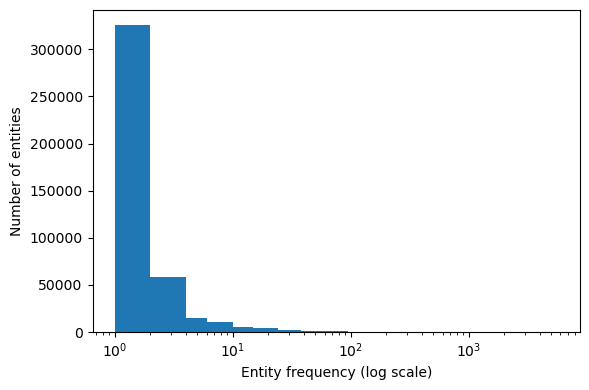

In [30]:
raw_frequencies_stats(drug_details_preclin)

In [31]:
drug_details_preclin.keys()

dict_keys(['unique_norm_to_id', 'unique_norm_to_id_with_parent', 'norm_frequency', 'mapped_to_ner', 'mapped_to_ner_df', 'raw_frequency', 'raw_to_first_id'])

In [32]:
mapped_drugs_to_ner_df = drug_details_preclin["mapped_to_ner_df"]
mapped_drugs_to_ner_df

,entity_mapping,entity,mapping,ner_tokens,ner_count
0,ng-nitroarginine methyl ester (C0083536),ng-nitroarginine methyl ester,C0083536,"[()-nitro-l-arginine methyl ester, (d)-nitro-l...",761
1,glucagon-like peptide 1 receptor agonist (C156...,glucagon-like peptide 1 receptor agonist,C1562104,"[(glp-1r) agonists, acting glp-2 analogs, acti...",346
2,"3 inhibitor, phosphodiesterase (C2267032)","3 inhibitor, phosphodiesterase",C2267032,"[(pde) inhibitors, 3'-5'-cyclic adenosine mono...",315
3,mk-801 (C0813872),mk-801,C0813872,"[(+ /-) mk-801, (+) mk-801, (+) mk801, (+))-mk...",294
4,histone deacetylase inhibitor (C1512474),histone deacetylase inhibitor,C1512474,[1 isoform-selective histone deacetylase inhib...,292
...,...,...,...,...,...
57161,"cyclin-dependent kinase 12 protein, human (C16...","cyclin-dependent kinase 12 protein, human",C1620114,[cdk12],1
57162,norcocaethylene (C0655454),norcocaethylene,C0655454,[norcocaethylene],1
57163,"complement c3u protein, human (C1437780)","complement c3u protein, human",C1437780,[c3u],1
57164,sr 31747a (C0380238),sr 31747a,C0380238,[sr 31747a],1


In [33]:
mapped_drugs_to_ner_df.to_csv("./data/linked_drugs_preclinical.csv", index=False)

In [34]:
drug_df, mapped_top10, unmapped_top10, side_by_side = top_mapped_unmapped_side_by_side(
    drug_details_preclin["unique_norm_to_id"],
    drug_details_preclin["norm_frequency"],
    entity_name="drug",
    unmapped_id="-1",
    top_n=10,
)

side_by_side


,Mapped Drug,Mapped Freq,Unmapped Drug,Unmapped Freq
0,ng-nitroarginine methyl ester,6609,inhibitor,1308
1,dexamethasone,6048,inhibitors,868
2,acetylcysteine,5452,antagonists,673
3,cyclosporine,4995,antagonist,577
4,cisplatin,4474,no donor,564
5,sirolimus,4392,selective serotonin reuptake inhibitor,540
6,doxorubicin,4076,ssris,517
7,melatonin,3856,selective serotonin reuptake inhibitors,508
8,estradiol,3725,pi3k inhibitor,498
9,glucocorticoids,3688,tyrosine kinase inhibitor,486


### clinical

In [35]:
clinical_drugs= "/shares/animalwelfare.crs.uzh/Clinical_Pipeline/data/linked_to_ontologies/mapped_clinical_drug_data_with_umls_parents.csv" #"/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/mapped_clinical_drug_data_with_umls_parents.csv"

df_drugs_cli = pd.read_csv(clinical_drugs)
#df_drugs_cli = df_drugs_cli[df_drugs_cli['nct_id'].isin(included_nctids['nct_id'])]
df_drugs_cli.shape, df_drugs_cli[['nct_id']].nunique()

((217488, 11),
 nct_id    217488
 dtype: int64)

In [36]:
df_drugs_cli.head()

,nct_id,ner_predicted_drugs,linkbert_umls_drugs,drug_umls_termid,drug_umls_term_norm,drug_umls_closest_3,drug_umls_cdist,nearest_dataset_parent_umls,nearest_dataset_parent_umls_label,merged_umls_termid,merged_umls_label
0,NCT00005972,gemcitabine | irinotecan,Gemcitabine|irinotecan,C0045093|C0123931,Gemcitabine|irinotecan,"[['Gemcitabine', 'C0045093'], ['gemcitabine', ...",0.0087|0.0068,-1,-1,C0045093|C0123931,Gemcitabine|irinotecan
1,NCT00005977,methotrexate,Methotrexate,C0025677,Methotrexate,"[['Methotrexate', 'C0025677'], ['methotrexate'...",0.0,-1,-1,C0025677,Methotrexate
2,NCT00005981,bcnu | o6benzylguanine,bcnu|o6-benzylguanine,C0007257|C0083812,Carmustine|O(6)-Benzylguanine,"[['bcnu', 'C0007257'], ['bcnu', 'C1516302'], [...",0.0087|5.5411,-1,-1,C0007257|C0083812,Carmustine|O(6)-Benzylguanine
3,NCT00005984,colony-stimulating factors | cyclophosphamide ...,colony-stimulating factors|Cyclophosphamide|fi...,C0009392|C0010583|-1|C0210630,Colony Stimulating Factor|Cyclophosphamide|fil...,"[['colony-stimulating factors', 'C0009392'], [...",0.0055|0.017|10.0943|0.0166,-1,-1,C0009392|C0010583|-1|C0210630,Colony Stimulating Factor|Cyclophosphamide|fil...
4,NCT00005986,colony-stimulating factors | filgrastim | g-cs...,colony-stimulating factors|Filgrastim|g-csf pr...,C0009392|C0210630|-1,Colony Stimulating Factor|Filgrastim|g-csf pri...,"[['colony-stimulating factors', 'C0009392'], [...",0.0055|0.0|11.9666,-1,-1,C0009392|C0210630|-1,Colony Stimulating Factor|Filgrastim|g-csf pri...


In [37]:
doc_id_col = "nct_id"
drug_raw_entities_col = "ner_predicted_drugs"
cols_to_keep = [
    doc_id_col,
    drug_raw_entities_col,
    drug_linked_entities_col,
    drug_linked_entities_ids,
    drug_parent_entities_col,
    drug_with_parents_entities_col,
    drug_with_parents_entities_ids,
]
df_to_analyse_cli_drugs = df_drugs_cli[cols_to_keep].copy()
df_to_analyse_cli = df_to_analyse_cli_drugs.copy()
df_to_analyse_cli.head()

,nct_id,ner_predicted_drugs,drug_umls_term_norm,drug_umls_termid,nearest_dataset_parent_umls_label,merged_umls_label,merged_umls_termid
0,NCT00005972,gemcitabine | irinotecan,Gemcitabine|irinotecan,C0045093|C0123931,-1,Gemcitabine|irinotecan,C0045093|C0123931
1,NCT00005977,methotrexate,Methotrexate,C0025677,-1,Methotrexate,C0025677
2,NCT00005981,bcnu | o6benzylguanine,Carmustine|O(6)-Benzylguanine,C0007257|C0083812,-1,Carmustine|O(6)-Benzylguanine,C0007257|C0083812
3,NCT00005984,colony-stimulating factors | cyclophosphamide ...,Colony Stimulating Factor|Cyclophosphamide|fil...,C0009392|C0010583|-1|C0210630,-1,Colony Stimulating Factor|Cyclophosphamide|fil...,C0009392|C0010583|-1|C0210630
4,NCT00005986,colony-stimulating factors | filgrastim | g-cs...,Colony Stimulating Factor|Filgrastim|g-csf pri...,C0009392|C0210630|-1,-1,Colony Stimulating Factor|Filgrastim|g-csf pri...,C0009392|C0210630|-1


In [38]:
df_to_analyse_cli["no_valid_mapping"] = (
    df_to_analyse_cli["drug_umls_termid"].apply(no_linked_entities)
)
perc_not_linked = df_to_analyse_cli.no_valid_mapping.sum()/len(df_to_analyse_cli)*100
df_to_analyse_cli.no_valid_mapping.sum(), 100-perc_not_linked

(25495, 88.27751416170088)

In [39]:
df_to_analyse_cli = add_unique_entity_count(
    df_to_analyse_cli,
    col="merged_umls_label"
)
summary = summarize_entities_per_document(
    df_to_analyse_cli,
    col="merged_umls_label_unique_count"
)

summary

{'mean': 2.5, 'std': 1.86, 'median': 2.0, 'min': 1, 'max': 59}

In [40]:
drug_report, drug_details = entity_linking_report(
    df=df_to_analyse_cli,
    ner_col=drug_raw_entities_col,  # raw
    norm_col="drug_umls_term_norm",                       # linked labels
    id_col="drug_umls_termid",                            # linked ids (aligned)
    parent_label_col="merged_umls_label",                 # linked + parent labels
    doc_id_col="nct_id",
    singularize=False
)
drug_report


Summarizing entity mappings for drug_umls_term_norm, drug_umls_termid
Summarizing entity mappings for merged_umls_label, merged_umls_termid
Only entities with more than 2 characters are considered.


,total mentions,count unique raw entities,count unique linked entities,count unique linked with parent,Linking success (unique / % mapped freq adjusted),mismatch rows (raw vs id length)
0,515010,116529,88412,88884,50257 (43.13%)/116529 (77.59%),0


In [41]:
unique_drugs_clinical = list(drug_details['unique_norm_to_id_with_parent'].keys())
len(unique_drugs_clinical)

88884

Entities appearing once: 82,084
Total unique entities: 116,529
Percentage singletons: 70.44%
Non-linked entities appearing once: 53,340 / 66,272 (80.49%)
Singletons linked: 28,744 / 82,084 (35.02%)
Entities of length smaller than 3: 0 
Short entities linked: 0 / 0 (0.00%)
Example singleton entities:
 - indocyanine green for injection mapped to C5200995
 - bs hh 002 mapped to -1
 - spn-820 mapped to C5940923
 - split influenza virus vaccine mapped to C0982212
 - aup1602-c mapped to -1
 - ic83 mapped to C3642428
 - gnrh-a down-down-regulation mapped to -1
 - intravenous infusion of glycerol/heparin mapped to -1
 - l04td2 mapped to -1
 - mk-1496 mapped to C4520216
Example short entities:
1–2: 82084
2–4: 19180
4–5: 3340
5–8: 4540
8–12: 2496
12–19: 1771
19–29: 1028
29–44: 673
44–67: 473
67–102: 322
102–155: 219
155–236: 152
236–359: 109
359–547: 69
547–833: 32
833–1268: 19
1268–1930: 11
1930–2938: 10
2938–2939: 1


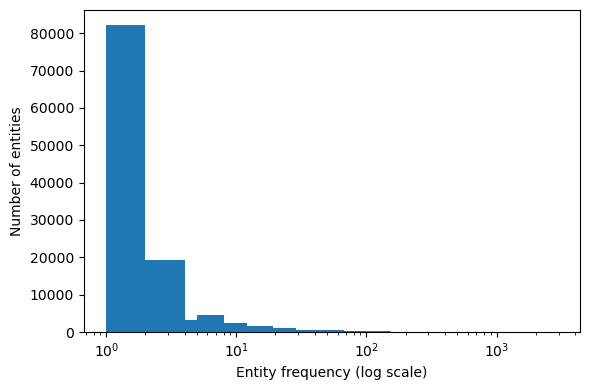

In [42]:
raw_frequencies_stats(drug_details)

In [43]:
drug_df, mapped_top10, unmapped_top10, side_by_side = top_mapped_unmapped_side_by_side(
    drug_details["unique_norm_to_id"],
    drug_details["norm_frequency"],
    entity_name="drug",
    unmapped_id="-1",
    top_n=10,
)

side_by_side


,Mapped Drug,Mapped Freq,Unmapped Drug,Unmapped Freq
0,cisplatin,3112,chemotherapy,1672
1,cyclophosphamide,2872,antidepressant,322
2,dexamethasone,2666,nsaids,263
3,paclitaxel,2657,proton pump inhibitor,259
4,gemcitabine,2541,folfox,225
5,carboplatin,2523,immunotherapy,205
6,bevacizumab,2515,tdf,204
7,metformin,2408,aromatase inhibitor,196
8,pembrolizumab,2353,xelox,193
9,rituximab,2215,antidepressants,180


## Disease entities

In [44]:
clinical_disesases = "/shares/animalwelfare.crs.uzh/Clinical_Pipeline/data/linked_to_ontologies/mapped_clinical_data_mondo_cleaned_with_mondo_parents.csv" #"/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/mapped_clinical_data_mondo_cleaned_with_mondo_parents.csv"
preclinical_disesases = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/mapped_preclinical_data_mondo_cleaned_with_mondo_parents.csv"

In [45]:
df_dis_cli = pd.read_csv(clinical_disesases)
#df_dis_cli = df_dis_cli[df_dis_cli['nct_id'].isin(included_nctids['nct_id'])]
df_dis_cli.shape

(217488, 13)

In [46]:
df_dis_pre = pd.read_csv(preclinical_disesases)
df_dis_pre.shape

(540999, 13)

In [47]:
df_dis_pre.head()

,PMID,unique_conditions_linkbert_predictions,linkbert_mondo_predictions,disease_mondo_termid,disease_mondo_term_norm,disease_mondo_closest_3,disease_mondo_cdist,disease_term_mondo_clean,disease_termid_mondo_clean,nearest_dataset_parent_mondo,nearest_dataset_parent_label,merged_mondo_termid,merged_mondo_label
0,31733831,asthma,asthma,MONDO:0004979,asthma,"[['asthma', 'MONDO:0004979'], ['asthma, bronch...",0.0068,asthma,MONDO:0004979,-1,-1,MONDO:0004979,asthma
1,31733833,myocardial infarction,myocardial infarction,MONDO:0005068,myocardial infarction,"[['myocardial infarction', 'MONDO:0005068'], [...",0.0,myocardial infarction,MONDO:0005068,-1,-1,MONDO:0005068,myocardial infarction
2,31733925,systemic lupus erythematosus,systemic lupus erythematosus,MONDO:0007915,systemic lupus erythematosus,"[['systemic lupus erythematosus', 'MONDO:00079...",0.0,systemic lupus erythematosus,MONDO:0007915,-1,-1,MONDO:0007915,systemic lupus erythematosus
3,31733940,cognitive impairment,cognitive disorder,MONDO:0002039,cognitive disorder,"[['cognitive disorder', 'MONDO:0002039'], ['co...",7.6573,cognitive disorder,MONDO:0002039,-1,-1,MONDO:0002039,cognitive disorder
4,31734027,cumulative peripheral neuropathy|oxaliplatin-i...,cumulative peripheral neuropathy|oxaliplatin-i...,-1|-1|MONDO:0003620,cumulative peripheral neuropathy|oxaliplatin-i...,"[['chronic acquired peripheral neuropathy', 'M...",9.8837|13.0604|0.0055,cumulative peripheral neuropathy|oxaliplatin-i...,-1|-1|MONDO:0003620,-1,-1,-1|-1|MONDO:0003620,cumulative peripheral neuropathy|oxaliplatin-i...


### preclinical

In [48]:
doc_id_col = "PMID"
disease_raw_entities_col = "unique_conditions_linkbert_predictions"

disease_linked_entities_col = "disease_mondo_term_norm"
disease_linked_entities_ids = "disease_mondo_termid"

cleaned_mondo_entities = "disease_term_mondo_clean"

disease_parent_entities_col = "nearest_dataset_parent_label"
disease_with_parents_entities_col = "merged_mondo_label"
disease_with_parents_entities_ids = "merged_mondo_termid"

cols_to_keep = [
    doc_id_col,
    disease_raw_entities_col,
    disease_linked_entities_col,
    disease_linked_entities_ids,
    cleaned_mondo_entities,
    disease_parent_entities_col,
    disease_with_parents_entities_col,
    disease_with_parents_entities_ids,
]
df_to_analyse_disease_preclin = df_dis_pre[cols_to_keep].copy()
df_to_analyse = df_to_analyse_disease_preclin.copy()
df_to_analyse.head()

,PMID,unique_conditions_linkbert_predictions,disease_mondo_term_norm,disease_mondo_termid,disease_term_mondo_clean,nearest_dataset_parent_label,merged_mondo_label,merged_mondo_termid
0,31733831,asthma,asthma,MONDO:0004979,asthma,-1,asthma,MONDO:0004979
1,31733833,myocardial infarction,myocardial infarction,MONDO:0005068,myocardial infarction,-1,myocardial infarction,MONDO:0005068
2,31733925,systemic lupus erythematosus,systemic lupus erythematosus,MONDO:0007915,systemic lupus erythematosus,-1,systemic lupus erythematosus,MONDO:0007915
3,31733940,cognitive impairment,cognitive disorder,MONDO:0002039,cognitive disorder,-1,cognitive disorder,MONDO:0002039
4,31734027,cumulative peripheral neuropathy|oxaliplatin-i...,cumulative peripheral neuropathy|oxaliplatin-i...,-1|-1|MONDO:0003620,cumulative peripheral neuropathy|oxaliplatin-i...,-1,cumulative peripheral neuropathy|oxaliplatin-i...,-1|-1|MONDO:0003620


In [49]:
df_to_analyse["no_valid_mapping"] = (
    df_to_analyse["disease_mondo_termid"].apply(no_linked_entities)
)
perc_no_mapping_at_all = df_to_analyse.no_valid_mapping.sum()/len(df_to_analyse)*100
df_to_analyse.no_valid_mapping.sum(), 100 - perc_no_mapping_at_all

(70447, 86.97834931303015)

In [50]:
df_to_analyse = add_unique_entity_count(
    df_to_analyse,
    col="merged_mondo_label"
)
summary = summarize_entities_per_document(
    df_to_analyse,
    col="merged_mondo_label_unique_count"
)

summary

{'mean': 1.89, 'std': 1.18, 'median': 2.0, 'min': 1, 'max': 24}

In [51]:
disease_report_preclin, disease_details_preclin = entity_linking_report(
    df=df_to_analyse,
    ner_col=disease_raw_entities_col,  # raw
    norm_col=disease_linked_entities_col,                       # linked labels
    id_col=disease_linked_entities_ids,                            # linked ids (aligned)
    parent_label_col=disease_with_parents_entities_col,                 # linked + parent labels
    doc_id_col="PMID",
    clean_label_col="disease_term_mondo_clean",
)
disease_report_preclin

Summarizing entity mappings for disease_mondo_term_norm, disease_mondo_termid
Summarizing entity mappings for merged_mondo_label, merged_mondo_termid
Only entities with more than 2 characters are considered.


,total mentions,count unique raw entities,count unique linked entities,count unique linked with parent,Linking success (unique / % mapped freq adjusted),mismatch rows (raw vs id length),count unique clean labels
0,1035001,123494,80123,79820,51158 (41.43%)/123494 (73.93%),0,79672


In [52]:
unique_disease_animal = list(disease_details_preclin['unique_norm_to_id_with_parent'].keys())
len(unique_disease_animal)

79820

In [53]:
disease_df, mapped_top10, unmapped_top10, side_by_side = top_mapped_unmapped_side_by_side(
    disease_details_preclin["unique_norm_to_id"],
    disease_details_preclin["norm_frequency"],
    entity_name="disease",
    unmapped_id="-1",
    top_n=10,
)
side_by_side

,Mapped Disease,Mapped Freq,Unmapped Disease,Unmapped Freq
0,ischemia reperfusion injury,23708,hypoxia,4331
1,epilepsy,19368,liver,2650
2,alzheimer disease,17855,stress,2445
3,diabetes mellitus,15451,oxidative stress,2296
4,ischemic disease,13451,focal cerebral ischemia,1904
5,parkinson disease,11941,i/r injury,1673
6,depressive disorder,10105,liver injury,1667
7,cerebral infarction,8911,hyperalgesia,1612
8,stroke disorder,8329,septic shock,1417
9,neuralgia,8197,shock,1412


In [54]:
mapped_diseases_to_ner_df = disease_details_preclin["mapped_to_ner_df"]
mapped_diseases_to_ner_df


,entity_mapping,entity,mapping,ner_tokens,ner_count
0,ischemia reperfusion injury (MONDO:0005203),ischemia reperfusion injury,MONDO:0005203,"[(i))-reperfusion, / reperfusion injury, / rep...",1378
1,perinatal asphyxia (MONDO:0006663),perinatal asphyxia,MONDO:0006663,"[acute asphyxia, acute hypoxic-ischemic (hi) e...",467
2,brain hypoxia - ischemia (MONDO:0006685),brain hypoxia - ischemia,MONDO:0006685,"[acute brain hypoxia, acute cerebral hypoxia, ...",302
3,brain ischemia (MONDO:0005299),brain ischemia,MONDO:0005299,"[acute and chronic brain ischemia, acute and c...",207
4,type 2 diabetes mellitus (MONDO:0005148),type 2 diabetes mellitus,MONDO:0005148,"[1 and 2 diabetes, 1 and 2 diabetic, 2 diabete...",184
...,...,...,...,...,...
7783,perichondritis of auricle (MONDO:0002246),perichondritis of auricle,MONDO:0002246,[perichondritis of],1
7784,osteopenia-intellectual disability-sparse hair...,osteopenia-intellectual disability-sparse hair...,MONDO:0009814,[oestrogen-deficiency osteopaenia],1
7785,disorder of sphingolipid biosynthesis (MONDO:0...,disorder of sphingolipid biosynthesis,MONDO:0021130,[sphingolipid disorders],1
7786,mucopolysaccharidosis or mucopolysaccharidosis...,mucopolysaccharidosis or mucopolysaccharidosis...,MONDO:0100365,[mucopolysaccharidosis-like disease],1


In [55]:
mapped_diseases_to_ner_df.to_csv("./data/linked_diseases_preclinical.csv", index=False)

### clinical

In [56]:
doc_id_col = "nct_id"
disease_raw_entities_col = "ner_predicted_conditions"
cols_to_keep = [
    doc_id_col,
    disease_raw_entities_col,
    disease_linked_entities_col,
    disease_linked_entities_ids,
    cleaned_mondo_entities,
    disease_parent_entities_col,
    disease_with_parents_entities_col,
    disease_with_parents_entities_ids,
]
df_to_analyse_cli_disease = df_dis_cli[cols_to_keep].copy()
df_to_analyse = df_to_analyse_cli_disease.copy()
df_to_analyse.head()

,nct_id,ner_predicted_conditions,disease_mondo_term_norm,disease_mondo_termid,disease_term_mondo_clean,nearest_dataset_parent_label,merged_mondo_label,merged_mondo_termid
0,NCT00005972,recurrent or refractory small cell lung cancer...,recurrent or refractory small cell lung cancer...,-1|MONDO:0008433|MONDO:0005070,recurrent or refractory small cell lung cancer...,lung neuroendocrine neoplasm|-1,recurrent or refractory small cell lung cancer...,-1|MONDO:0008433|MONDO:0005070|MONDO:0005454
1,NCT00005977,acute lymphocytic leukemia | advanced-stage (i...,acute lymphoblastic leukemia|advanced-stage (i...,MONDO:0004967|-1|MONDO:0020511|MONDO:0004992|M...,acute lymphoblastic leukemia|advanced-stage (i...,-1|-1|-1|-1,acute lymphoblastic leukemia|advanced-stage (i...,MONDO:0004967|-1|MONDO:0020511|MONDO:0004992|M...
2,NCT00005981,colon and | metastatic colorectal cancer | rec...,malignant colon neoplasm|metastatic malignant ...,MONDO:0021063|MONDO:0041447|MONDO:0044937|MOND...,malignant colon neoplasm|metastatic malignant ...,-1|metastatic malignant neoplasm|-1|-1,malignant colon neoplasm|metastatic malignant ...,MONDO:0021063|MONDO:0041447|MONDO:0044937|MOND...
3,NCT00005984,chronic myelogenous leukemia stem cells | chro...,"acute undifferentiated leukemia|leukemia, myel...",MONDO:0020321|MONDO:0021367|-1,"acute undifferentiated leukemia|leukemia, myel...",acute leukemia of ambiguous lineage|-1,"acute undifferentiated leukemia|leukemia, myel...",MONDO:0020321|MONDO:0021367|-1|MONDO:0019460
4,NCT00005986,cancer | chronic myelogenous leukemia | chroni...,"cancer|chronic myelogenous leukemia, BCR-ABL1 ...",MONDO:0004992|MONDO:0011996|-1,"cancer|chronic myelogenous leukemia, BCR-ABL1 ...",-1|-1,"cancer|chronic myelogenous leukemia, BCR-ABL1 ...",MONDO:0004992|MONDO:0011996|-1


In [57]:
df_to_analyse["no_valid_mapping"] = (
    df_to_analyse["disease_mondo_termid"].apply(no_linked_entities)
)
perc_no_mapping_at_all = df_to_analyse.no_valid_mapping.sum()/len(df_to_analyse)*100
df_to_analyse.no_valid_mapping.sum(), 100 - perc_no_mapping_at_all

(52348, 75.93062605752961)

In [58]:
df_to_analyse = add_unique_entity_count(
    df_to_analyse,
    col="merged_mondo_label"
)
summary = summarize_entities_per_document(
    df_to_analyse,
    col="merged_mondo_label_unique_count"
)

summary

{'mean': 2.82, 'std': 2.0, 'median': 2.0, 'min': 1, 'max': 90}

In [59]:
(123919 - 80349)/123919

0.3516006423550868

In [60]:
disease_report, disease_details = entity_linking_report(
    df=df_to_analyse,
    ner_col=disease_raw_entities_col,  # raw
    norm_col=disease_linked_entities_col,                       # linked labels
    id_col=disease_linked_entities_ids,                            # linked ids (aligned)
    parent_label_col=disease_with_parents_entities_col,                 # linked + parent labels
    doc_id_col="nct_id",
    clean_label_col="disease_term_mondo_clean",
)
disease_report

Summarizing entity mappings for disease_mondo_term_norm, disease_mondo_termid
Summarizing entity mappings for merged_mondo_label, merged_mondo_termid
Only entities with more than 2 characters are considered.


,total mentions,count unique raw entities,count unique linked entities,count unique linked with parent,Linking success (unique / % mapped freq adjusted),mismatch rows (raw vs id length),count unique clean labels
0,614840,162417,122850,122807,46465 (28.61%)/162417 (53.77%),0,122679


In [61]:
unique_disease_clinical = list(disease_details['unique_norm_to_id_with_parent'].keys())
len(unique_disease_clinical)

122807

Entities appearing once: 123,437
Total unique entities: 162,417
Percentage singletons: 76.00%
Non-linked entities appearing once: 92,821 / 115,952 (80.05%)
Singletons linked: 30,616 / 123,437 (24.80%)
Entities of length smaller than 3: 0 
Short entities linked: 0 / 0 (0.00%)
Example singleton entities:
 - mud and mmud transplantation mapped to -1
 - peri-implants mucositis mapped to -1
 - diffuse large b-cell lymphoma remission mapped to -1
 - acutely hiv-1 infected mapped to -1
 - resectable early stage gastroesophageal adenocarcinoma mapped to -1
 - advanced crpc mapped to MONDO:0850353
 - stage iiib or iv non small cell lung cancer mapped to -1
 - infraclavicular brachial plexus block surgeries mapped to -1
 - lchad associated neuropathy mapped to -1
 - insulin requiring diabetes mellitus mapped to MONDO:0009100
Example short entities:
1–2: 123437
2–3: 16491
3–4: 6266
4–7: 7144
7–11: 3159
11–18: 2177
18–30: 1459
30–48: 843
48–79: 579
79–128: 365
128–208: 200
208–337: 139
337–548: 76

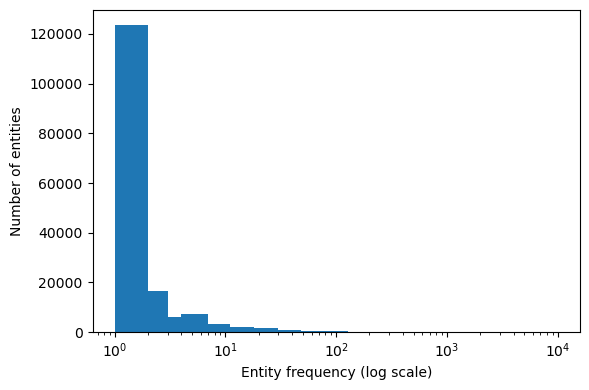

In [62]:
raw_frequencies_stats(disease_details)

In [63]:
disease_df, mapped_top10, unmapped_top10, side_by_side = top_mapped_unmapped_side_by_side(
    disease_details["unique_norm_to_id"],
    disease_details["norm_frequency"],
    entity_name="disease",
    unmapped_id="-1",
    top_n=10,
)
side_by_side

,Mapped Disease,Mapped Freq,Unmapped Disease,Unmapped Freq
0,neoplasm,11976,healthy,5729
1,cancer,10024,advanced solid tumors,2688
2,obsolete disorder involving pain,8190,healthy volunteers,1546
3,type 2 diabetes mellitus,7006,solid tumors,1462
4,hiv infectious disease,6106,postoperative pain,1460
5,obesity disorder,4393,chemotherapy,1444
6,covid-19,3912,surgery,1054
7,diabetes mellitus,3461,postmenopausal,1041
8,non-small cell lung carcinoma,3370,radiation therapy,873
9,depressive disorder,2809,metastatic breast cancer,846


# Drug-Disease Pairs

### preclinical

In [64]:
FILE_PRECLINICAL_LINKING = "/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/04_normalization/data/mapped_all/entities_drug_disease_preclin.csv"
preclinical_df = pd.read_csv(FILE_PRECLINICAL_LINKING)

# DISEASE
conditions_col_to_use ="merged_mondo_label"
cols_to_explode = [
    "merged_mondo_label",
    "merged_mondo_termid"
    
]

for col in cols_to_explode:
    preclinical_df[col] = preclinical_df[col].astype(str).str.split("|")

preclinical_df = preclinical_df.explode(cols_to_explode, ignore_index=True)
print(f"Unique disease before length filter: {preclinical_df[conditions_col_to_use].nunique()}")
preclinical_df = preclinical_df[preclinical_df[conditions_col_to_use].fillna("").str.len() > 2]
print(f"Unique disease: {preclinical_df[conditions_col_to_use].nunique()}")

# DRUG
drugs_col_to_use = "merged_umls_label"
cols_to_explode = [
    drugs_col_to_use,     # e.g. drug names
    "merged_umls_termid",             # IDs
    
]

for col in cols_to_explode:
    preclinical_df[col] = preclinical_df[col].astype(str).str.split("|")

preclinical_df = preclinical_df.explode(cols_to_explode, ignore_index=True)
print(f"Unique drugs before length filter: {preclinical_df[drugs_col_to_use].nunique()}")

preclinical_df = preclinical_df[preclinical_df[drugs_col_to_use].fillna("").str.len() > 2]
print(f"Unique drugs: {preclinical_df[drugs_col_to_use].nunique()}")

preclinical_df = preclinical_df.drop_duplicates()

# Strip whitespace and convert to lowercase
preclinical_df[conditions_col_to_use] = preclinical_df[conditions_col_to_use].str.strip().str.lower()
preclinical_df[drugs_col_to_use] = preclinical_df[drugs_col_to_use].str.strip().str.lower()

Unique disease before length filter: 80055
Unique disease: 79820
Unique drugs before length filter: 292588
Unique drugs: 291540


In [65]:
preclinical_df['disease<>drug'] = (
    preclinical_df[conditions_col_to_use] + " <> " + preclinical_df[drugs_col_to_use]
)

In [66]:
preclinical_pairs = set(preclinical_df['disease<>drug'])

### clinical

In [67]:
# --- Load Clinical Data ---
FILE_CLINICAL_LINKING = "/scratch/sdonev/Clinical_Pipeline/data/linked_to_ontologies/entities_drug_disease_clin.csv" #"_neuro.csv"
clinical_df = pd.read_csv(FILE_CLINICAL_LINKING)
print(f"Shape of clinical_df: {clinical_df.shape}, {clinical_df.nct_id.nunique()} unique NCTIDs")

# DISEASE
conditions_col_to_use_clinical ="merged_mondo_label"
cols_to_explode = [
    conditions_col_to_use_clinical,
    "merged_mondo_termid"
    
]

for col in cols_to_explode:
    clinical_df[col] = clinical_df[col].astype(str).str.split("|")

clinical_df = clinical_df.explode(cols_to_explode, ignore_index=True)
print(f"Unique disease before length filter: {clinical_df[conditions_col_to_use_clinical].nunique()}")
clinical_df = clinical_df[clinical_df[conditions_col_to_use_clinical].fillna("").str.len() > 2]
print(f"Unique disease: {clinical_df[conditions_col_to_use_clinical].nunique()}")

# DRUG
drugs_col_to_use_clinical = "merged_umls_label"
cols_to_explode = [
    drugs_col_to_use_clinical,     # e.g. drug names
    "merged_umls_termid",             # IDs
]

for col in cols_to_explode:
    clinical_df[col] = clinical_df[col].astype(str).str.split("|")

clinical_df = clinical_df.explode(cols_to_explode, ignore_index=True)
print(f"Unique drugs before length filter: {clinical_df[drugs_col_to_use_clinical].nunique()}")
clinical_df = clinical_df[clinical_df[drugs_col_to_use_clinical].fillna("").str.len() > 2]
print(f"Unique drugs: {clinical_df[drugs_col_to_use_clinical].nunique()}")

# Strip whitespace and convert to lowercase
clinical_df[conditions_col_to_use_clinical] = clinical_df[conditions_col_to_use_clinical].str.strip().str.lower()
clinical_df[drugs_col_to_use_clinical] = clinical_df[drugs_col_to_use_clinical].str.strip().str.lower()


Shape of clinical_df: (217488, 18), 217488 unique NCTIDs
Unique disease before length filter: 148951
Unique disease: 148686
Unique drugs before length filter: 90539
Unique drugs: 90073


In [68]:
clinical_df['disease<>drug'] = (
    clinical_df[conditions_col_to_use_clinical] + " <> " + clinical_df[drugs_col_to_use_clinical]
)

In [69]:
clinical_pairs = set(clinical_df['disease<>drug'])

# Preclinical-Clinical Overlaps

In [70]:
def rank_entities_by_frequency(
    entities,
    frequency_dict,
    id_mapping_dict,
    top_n=20,
    linked_filter="all"   # "all", "linked", "unlinked"
):
    """
    Rank entities by frequency with optional filtering by linkage status.

    Parameters
    ----------
    entities : set or list
        Entities to evaluate.
    frequency_dict : dict
        Mapping entity -> frequency.
    id_mapping_dict : dict
        Mapping entity -> identifier (e.g. CUI).
    top_n : int
        Number of top results to return.
    linked_filter : str
        "all", "linked", or "unlinked"

    Returns
    -------
    pandas.DataFrame
    """

    results = []

    for ent in entities:
        freq = frequency_dict.get(ent, 0)
        entity_id = id_mapping_dict.get(ent)
        linked = entity_id != "-1"

        if (
            linked_filter == "all"
            or (linked_filter == "linked" and linked)
            or (linked_filter == "unlinked" and not linked)
        ):
            results.append({
                "entity": ent,
                "frequency": freq,
                "id": entity_id,
                "linked": linked
            })

    df = pd.DataFrame(results).sort_values("frequency", ascending=False)

    return df.head(top_n)

In [71]:
def print_overlap_stats(name, set_a, set_b):
    only_a = set_a - set_b
    only_b = set_b - set_a
    overlap = set_a & set_b
    union = set_a | set_b

    print(f"\n=== {name.upper()} ===")
    print(f"A (Clinical/FDA): {len(set_a):,}")
    print(f"B (Animal):       {len(set_b):,}")
    print(f"Overlap:          {len(overlap):,}")
    print(f"Only A:           {len(only_a):,}")
    print(f"Only B:           {len(only_b):,}")
    print(f"Union:            {len(union):,}")

    if len(union) > 0:
        jaccard = len(overlap) / len(union)
        print(f"Jaccard index:    {jaccard:.3f}")

    if len(set_a) > 0:
        print(f"% of A in B:      {len(overlap)/len(set_a)*100:.1f}%")
    if len(set_b) > 0:
        print(f"% of B in A:      {len(overlap)/len(set_b)*100:.1f}%")


In [72]:
# DRUGS
fda_drugs_only = pd.read_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/10_use_case_disease_focus/out/df_ds_drugs_with_FDA_info.csv")
set_fda_drugs = set(fda_drugs_only['merged_umls_label'])
fda_drugs = {str(x).strip().lower() for x in set_fda_drugs if x}
clinical_drugs = {str(x).strip().lower() for x in unique_drugs_clinical if x}
preclinical_drugs = {str(x).strip().lower() for x in unique_drugs_animal if x}

# DISEASE

fda_drug_disease = pd.read_csv("/shares/animalwelfare.crs.uzh/Preclinical_Pipeline/10_use_case_disease_focus/out/FDA_drug_disease_pairs_mapped_both.csv")
fda_drug_disease['disease<>drug'] = (
    fda_drug_disease["disease_mondo_term_norm"] + " <> " + fda_drug_disease["merged_umls_label"]
)
fda_disease = set(fda_drug_disease['disease_mondo_term_norm'])
fda_disease_set = {str(x).strip().lower() for x in fda_disease if x}
clinical_disease_set = {str(x).strip().lower() for x in unique_disease_clinical if x}
preclinical_disease_set = {str(x).strip().lower() for x in unique_disease_animal if x}

# PAIRS
fda_pairs = set(fda_drug_disease['disease<>drug'])
fda_pairs_set = {str(x).strip().lower() for x in fda_pairs if x}
clinical_pairs_set = {str(x).strip().lower() for x in clinical_pairs if x}
preclinical_pairs_set = {str(x).strip().lower() for x in preclinical_pairs if x}

In [73]:
# ---------- run stats ----------
print_overlap_stats(
    "drugs",
    clinical_drugs.union(fda_drugs),
    preclinical_drugs
)

print_overlap_stats(
    "diseases",
    clinical_disease_set.union(fda_disease_set),
    preclinical_disease_set
)

print_overlap_stats(
    "drug-disease pairs",
    clinical_pairs_set.union(fda_pairs_set),
    preclinical_pairs_set
)


=== DRUGS ===
A (Clinical/FDA): 89,159
B (Animal):       291,624
Overlap:          19,419
Only A:           69,740
Only B:           272,205
Union:            361,364
Jaccard index:    0.054
% of A in B:      21.8%
% of B in A:      6.7%

=== DISEASES ===
A (Clinical/FDA): 123,701
B (Animal):       79,820
Overlap:          11,664
Only A:           112,037
Only B:           68,156
Union:            191,857
Jaccard index:    0.061
% of A in B:      9.4%
% of B in A:      14.6%

=== DRUG-DISEASE PAIRS ===
A (Clinical/FDA): 1,310,485
B (Animal):       1,807,945
Overlap:          78,638
Only A:           1,231,847
Only B:           1,729,307
Union:            3,039,792
Jaccard index:    0.026
% of A in B:      6.0%
% of B in A:      4.3%


In [74]:
drugs_animal_not_clinical = preclinical_drugs - clinical_drugs
drugs_clinical_not_animal = clinical_drugs - preclinical_drugs

In [75]:
top_entities = rank_entities_by_frequency(
    drugs_clinical_not_animal,
    drug_details['norm_frequency'],
    drug_details['unique_norm_to_id_with_parent'],
    top_n=10
)
top_entities

,entity,frequency,id,linked
21980,mk-3475,342,C3660977,True
2812,medi4736,278,C3641122,True
23720,adebrelimab,241,C5432273,True
27129,human papilloma virus vaccines,223,C1512511,True
28908,covid-19 vaccine,222,C5400806,True
14699,"influenza virus,quadrivalent split vaccine",216,C3663037,True
38707,"influenza vaccine, trivalent",209,C0770694,True
14167,xelox,193,-1,False
32692,xeloda,181,C0724419,True
67015,cemiplimab,167,C4724806,True


In [76]:
top_entities = rank_entities_by_frequency(
    drugs_animal_not_clinical,
    drug_details_preclin['norm_frequency'],
    drug_details_preclin['unique_norm_to_id_with_parent'],
    top_n=10
)
top_entities

,entity,frequency,id,linked
214761,mk-801,3340,C0813872,True
178762,sb 203580,1547,C0297666,True
96506,pd-98059,1411,C0298346,True
22458,sodium bisulfide,1332,C0074725,True
224814,u 0126,1290,C0755562,True
97661,wortmannin,1033,C0078517,True
222962,sp600125,975,C0968383,True
33749,sch 23390,965,C0080138,True
189522,bicuculline,961,C0005372,True
113771,3-methyladenine,941,C0047569,True


In [77]:
top_entities = rank_entities_by_frequency(
    drugs_animal_not_clinical,
    drug_details_preclin['norm_frequency'],
    drug_details_preclin['unique_norm_to_id_with_parent'],
    top_n=10,
    linked_filter="unlinked"
)
top_entities

,entity,frequency,id,linked
191927,receptor,441,-1,False
208215,h2s donor,334,-1,False
111289,nos inhibitor,332,-1,False
55054,res,248,-1,False
68577,nf-κb inhibitor,239,-1,False
144361,ampk inhibitor,236,-1,False
136147,inhibition,194,-1,False
22726,nadph oxidase inhibitor,187,-1,False
57215,nos inhibitors,187,-1,False
110224,sirt1 inhibitor,180,-1,False


In [78]:
disease_clinical_not_animal = clinical_disease_set - preclinical_disease_set

In [79]:
top_entities = rank_entities_by_frequency(
    disease_clinical_not_animal,
    disease_details['norm_frequency'],
    disease_details['unique_norm_to_id_with_parent'],
    top_n=10,
)
top_entities

,entity,frequency,id,linked
101265,healthy,5729,-1,False
82038,healthy volunteers,1546,-1,False
78762,cardiac surgery,786,-1,False
10093,hemodialysis,746,-1,False
79574,healthy subjects,576,-1,False
3671,critically ill,565,-1,False
4,newly diagnosed,561,-1,False
46151,previously untreated,542,-1,False
75360,percutaneous coronary intervention,487,-1,False
68928,cesarean section,452,-1,False


In [80]:
top_entities = rank_entities_by_frequency(
    disease_clinical_not_animal,
    disease_details['norm_frequency'],
    disease_details['unique_norm_to_id_with_parent'],
    top_n=10,
    linked_filter="linked"
)
top_entities

,entity,frequency,id,linked
1656,obsolete moderate covid-19 infection,311,MONDO:0100141,True
1395,severe hemophilia a,185,MONDO:0015719,True
1426,"hypercholesterolemia, familial, 1",107,MONDO:0007750,True
49,splenic marginal zone lymphoma,101,MONDO:0019462,True
1410,obsolete glioblastoma multiforme,94,MONDO:0002498,True
483,obsolete mild covid-19 infection,89,MONDO:0100140,True
298,retinitis pigmentosa 1,82,MONDO:0008377,True
1251,pseudohypoaldosteronism type 2,75,MONDO:0019162,True
96,myotonic dystrophy type 1,57,MONDO:0008056,True
207,severe nonproliferative diabetic retinopathy,57,MONDO:0004687,True


In [81]:
FILE_CLINICAL_METADATA = "/scratch/sdonev/Clinical_Pipeline/data/raw_aact/mv_interventional_drug_studies_20260302.csv" #_neuro.csv"
metadata_df = pd.read_csv(FILE_CLINICAL_METADATA)[['nct_id', 'phase', 'overall_status', 'start_date', 'completion_date','study_first_submitted_date']]
clinical_df_with_metadata = clinical_df.merge(metadata_df, on='nct_id', how='left')[['nct_id','merged_mondo_label','merged_umls_label','phase']]


In [82]:
clinical_df_with_metadata[
    clinical_df_with_metadata['merged_mondo_label'].str.contains("healthy", case=False, na=False)
]['phase'].value_counts()

phase
PHASE1           19405
PHASE4             952
PHASE2             551
PHASE3             513
EARLY_PHASE1       348
PHASE1/PHASE2      335
PHASE2/PHASE3       65
Name: count, dtype: int64

## viz Venn

89159
[Text(-0.22964664448859287, 1.3874573303837193e-17, '272205'), Text(0.5574289037232179, 0.0, '69740'), Text(0.27718561839152245, 1.715995211819996e-17, '19419')]
[Text(-0.4774694798805892, -5.456860032146777e-18, '68156'), Text(0.33946464149649935, 0.0, '112037'), Text(-0.11356106284298212, 2.7739823937541058e-17, '11664')]
[Text(-0.3464393955868251, 3.95962435882458e-18, '1729307'), Text(0.4591083636055272, 0.0, '1231847'), Text(0.08866727058570453, 2.268297494196864e-17, '78638')]


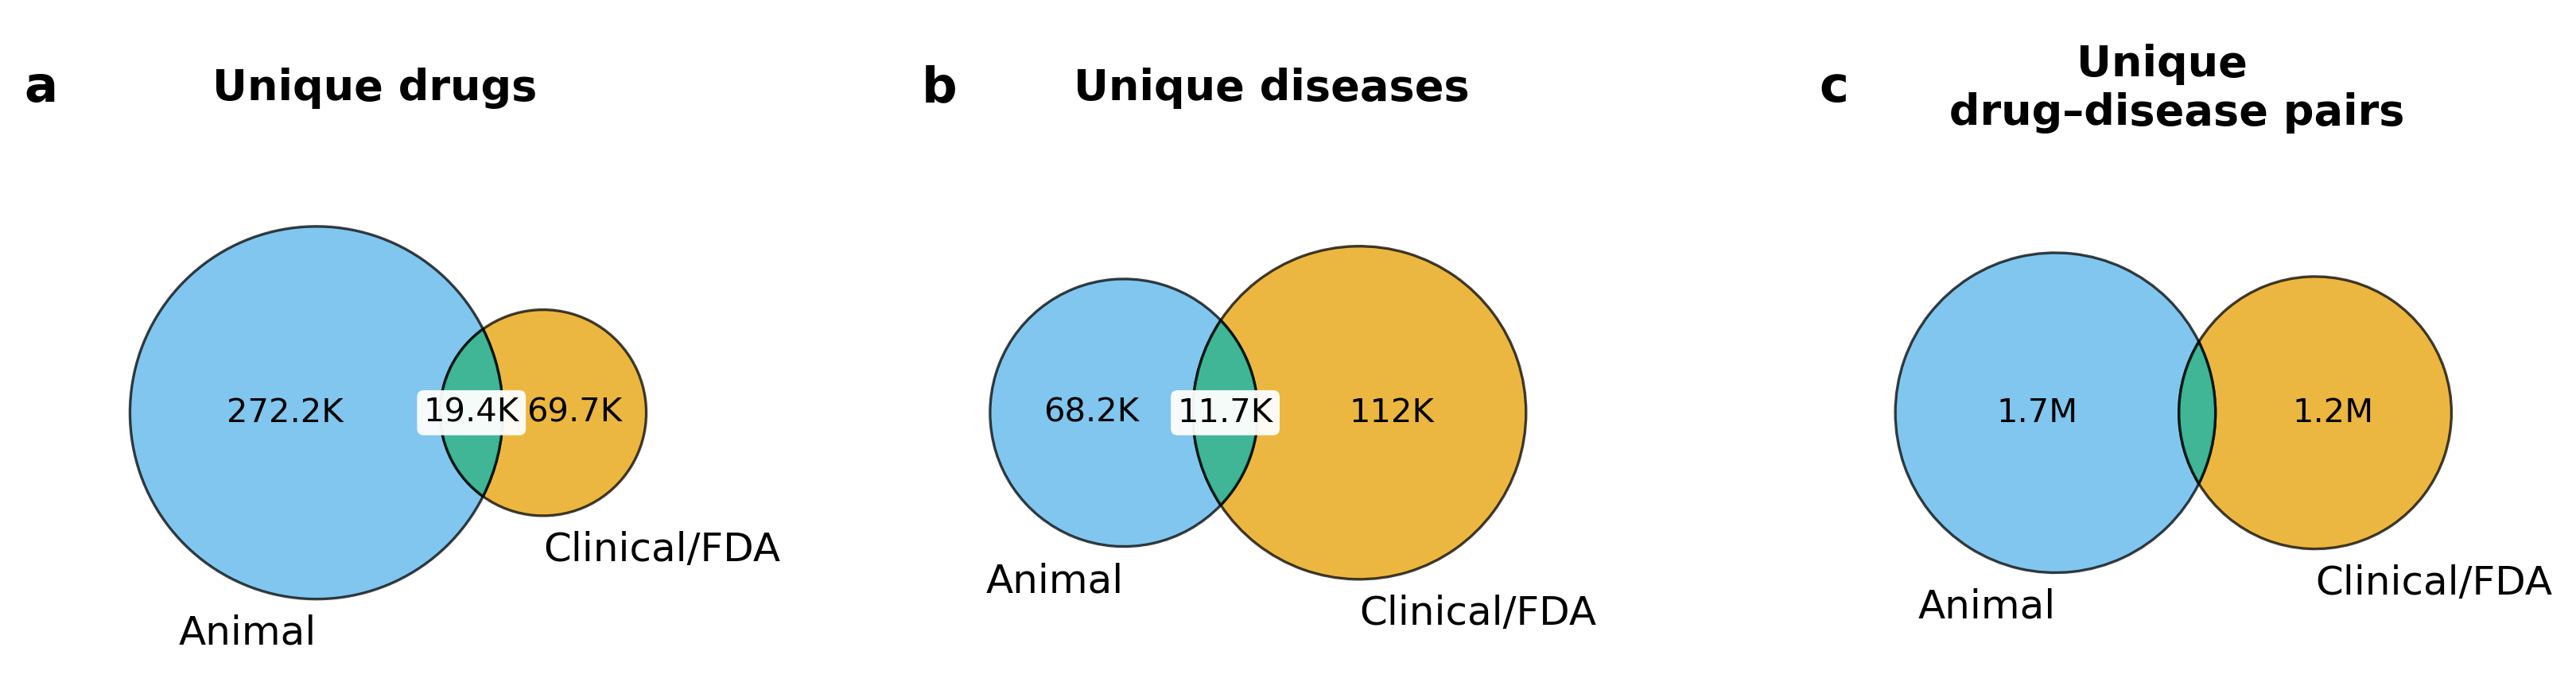

In [86]:
import os
import matplotlib.pyplot as plt
from matplotlib_venn import venn2
from matplotlib.transforms import Bbox

# ---------- helpers ----------
def human_format(num):
    num = float(num)
    for unit in ["", "K", "M", "B"]:
        if abs(num) < 1000:
            return f"{num:.1f}".rstrip("0").rstrip(".") + unit
        num /= 1000
    return f"{num:.1f}".rstrip("0").rstrip(".") + "T"

def format_venn_labels(v, fontsize=10, mode="compact"):
    print(v.subset_labels)
    for text in v.subset_labels:
        if text is not None:
            raw = text.get_text().replace(",", "").strip()
            if raw:
                try:
                    value = int(raw)
                    text.set_text(f"{value:,}" if mode == "comma" else human_format(value))
                except ValueError:
                    pass
            text.set_fontsize(fontsize)
            text.set_fontweight("normal")

    for text in v.set_labels:
        if text is not None:
            text.set_fontsize(fontsize)
            text.set_fontweight("normal")

def style_venn2(v, color_left="#56B4E9", color_right="#E69F00", color_overlap="#009E73"):
    # 10 = left-only, 01 = right-only, 11 = overlap
    for pid, color in {"10": color_left, "01": color_right, "11": color_overlap}.items():
        patch = v.get_patch_by_id(pid)
        if patch is not None:
            patch.set_color(color)
            patch.set_alpha(0.75)
            patch.set_edgecolor("black")
            patch.set_linewidth(0.8)

def beautify_subset_labels(v, set_overlap_text=True):
    for pid in ["10", "01", "11"]:
        text = v.get_label_by_id(pid)
        if text is None:
            continue

        if pid == "11" and not set_overlap_text:
            text.set_visible(False)
            continue

        text.set_color("black")
        text.set_fontsize(10)

    overlap_text = v.get_label_by_id("11")
    if (overlap_text is not None) and set_overlap_text:
        overlap_text.set_bbox(dict(
            boxstyle="round,pad=0.2",
            facecolor="white",
            edgecolor="none",
            alpha=0.95
        ))

def standardize_venn_axes(axes, pad=0.05):
    xmins, xmaxs, ymins, ymaxs = [], [], [], []
    for ax in axes:
        xmin, xmax = ax.get_xlim()
        ymin, ymax = ax.get_ylim()
        xmins.append(xmin)
        xmaxs.append(xmax)
        ymins.append(ymin)
        ymaxs.append(ymax)

    xmin, xmax = min(xmins), max(xmaxs)
    ymin, ymax = min(ymins), max(ymaxs)

    dx = xmax - xmin
    dy = ymax - ymin

    xmin -= pad * dx
    xmax += pad * dx
    ymin -= pad * dy
    ymax += pad * dy

    for ax in axes:
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal")
        ax.set_anchor("C")

def save_panel(fig, title_ax, panel_ax, outpath, pad=0.03):
    """
    Save one title+panel pair from a multi-panel figure.
    """
    fig.canvas.draw()
    renderer = fig.canvas.get_renderer()

    tb = title_ax.get_tightbbox(renderer)
    pb = panel_ax.get_tightbbox(renderer)
    bbox = Bbox.union([tb, pb])

    # small padding in inches
    bbox_inches = bbox.transformed(fig.dpi_scale_trans.inverted())
    bbox_inches = Bbox.from_extents(
        bbox_inches.x0 - pad,
        bbox_inches.y0 - pad,
        bbox_inches.x1 + pad,
        bbox_inches.y1 + pad
    )

    fig.savefig(outpath, bbox_inches=bbox_inches)

# ---------- global style ----------
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "figure.dpi": 300,
    "savefig.dpi": 300,
})

os.makedirs("viz", exist_ok=True)

# ---------- layout ----------
fig = plt.figure(figsize=(13.5, 3.8))
gs = fig.add_gridspec(
    2, 3,
    height_ratios=[0.12, 1.0],
    hspace=0.02,
    wspace=0.28
)

title_axes = [fig.add_subplot(gs[0, i]) for i in range(3)]
axes = [fig.add_subplot(gs[1, i]) for i in range(3)]

titles = ["Unique drugs", "Unique diseases", "Unique \n drug–disease pairs"]
letters = ["a", "b", "c"]

# filenames for individual export
panel_files = [
    "viz/venn_unique_drugs.svg",
    "viz/venn_unique_diseases.svg",
    "viz/venn_unique_drug_disease_pairs.svg"
]

# Top row: perfectly aligned titles and panel letters
for tax, t, letter in zip(title_axes, titles, letters):
    tax.axis("off")
    tax.text(0.00, 0.125, letter, ha="left", va="center",
             fontsize=15, fontweight="bold")
    tax.text(0.50, 0.125, t, ha="center", va="center",
             fontsize=13, fontweight="bold")

# ---------- venn panels ----------
# Put Animal on the left, Clinical/FDA on the right
print(len(clinical_drugs.union(fda_drugs)))
v1 = venn2(
    [preclinical_drugs, clinical_drugs.union(fda_drugs)],
    set_labels=("Animal", "Clinical/FDA"),
    ax=axes[0]
)
style_venn2(v1, color_left="#56B4E9", color_right="#E69F00", color_overlap="#009E73")
format_venn_labels(v1, fontsize=12, mode="compact")
beautify_subset_labels(v1)

v2 = venn2(
    [preclinical_disease_set, clinical_disease_set.union(fda_disease_set)],
    set_labels=("Animal", "Clinical/FDA"),
    ax=axes[1]
)
style_venn2(v2, color_left="#56B4E9", color_right="#E69F00", color_overlap="#009E73")
format_venn_labels(v2, fontsize=12, mode="compact")
beautify_subset_labels(v2)

v3 = venn2(
    [preclinical_pairs, clinical_pairs.union(fda_pairs_set)],
    set_labels=("Animal", "Clinical/FDA"),
    ax=axes[2]
)
style_venn2(v3, color_left="#56B4E9", color_right="#E69F00", color_overlap="#009E73")
format_venn_labels(v3, fontsize=12, mode="compact")
beautify_subset_labels(v3, set_overlap_text=False)

# Make all panels use the same visual frame
standardize_venn_axes(axes)

# ---------- save combined ----------
fig.savefig("viz/venn_3panel_entity_overlaps.pdf", bbox_inches="tight")

# ---------- save each panel individually ----------
for tax, ax, outpath in zip(title_axes, axes, panel_files):
    save_panel(fig, tax, ax, outpath)

plt.show()

In [98]:
272.2 + 19.4

291.59999999999997

In [99]:
78.6 + 1.7

80.3